<a href="https://colab.research.google.com/github/IvanovaKaryna/-/blob/main/%D0%9B%D0%A0_2_2_%D0%86%D0%B2%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0_3_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторна робота 2. Іванова, 3-10**

### **Була присутня на парі**

# **Завдання 2**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 21.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahmoudshogaa/titanic-dataset/versions/1


In [4]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. Визначити розмір датасета

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


3. Визначити тип датасету

In [6]:
df.duplicated().sum()

np.int64(0)

4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


5. Ще раз перевірити наявність пропущених значень.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]




In [9]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)


In [10]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df

/tmp/ipykernel_1123/3343465709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500
...,...,...,...,...,...
886,0,2,0,27.0,13.0000
887,1,1,1,19.0,30.0000
888,0,3,1,NaN,23.4500
889,1,1,0,26.0,30.0000



8. Вивести описову статистику датасету describe()



In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,14.526497,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,38.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).



In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
Fare,0


In [14]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

/tmp/ipykernel_1123/1841944837.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].fillna(df['Age'].mean())


In [15]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.


In [16]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500



11. Вивести 5 останніх рядків датасету.



In [17]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.000000,13.00
887,1,1,1,19.000000,30.00
888,0,3,1,29.699118,23.45
889,1,1,0,26.000000,30.00
890,0,3,0,32.000000,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?


In [18]:
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
print("Чоловіки:", round(survival_sex[0], 2), "%")
print("Жінки:", round(survival_sex[1], 2), "%")

Чоловіки: 18.89 %
Жінки: 74.2 %



13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?



In [23]:
for class_num, value in survival_class.items():
    print(f"{class_num} клас: {value:.2f}%")

1 клас: 62.96%
2 клас: 47.28%
3 клас: 24.24%


14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?



In [22]:
mean_age = df.groupby('Survived')['Age'].mean()

print("Середній вік тих, хто не вижив:", round(mean_age[0], 2))
print("Середній вік тих, хто вижив:", round(mean_age[1], 2))

Середній вік тих, хто не вижив: 30.42
Середній вік тих, хто вижив: 28.55


15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?



In [24]:
df['FareGroup'] = pd.qcut(df['Fare'], 4)

fare_survival = df.groupby('FareGroup', observed=True)['Survived'].mean() * 100
fare_survival

/tmp/ipykernel_1123/1051477597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FareGroup'] = pd.qcut(df['Fare'], 4)


,Survived
FareGroup,
"(-0.001, 7.91]",19.730942
"(7.91, 14.454]",30.357143
"(14.454, 31.0]",45.495495
"(31.0, 512.329]",58.108108


16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?



In [25]:
mean_fare = df.groupby('Pclass')['Fare'].mean()

for class_num, value in mean_fare.items():
    print(f"{class_num} клас: {value:.2f}")

1 клас: 84.15
2 клас: 20.66
3 клас: 13.68


17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічноЯк пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно


In [26]:
age_survival = df.groupby('Survived')['Age'].mean()

print("Середній вік тих, хто не вижив:", round(age_survival[0], 2))
print("Середній вік тих, хто вижив:", round(age_survival[1], 2))

Середній вік тих, хто не вижив: 30.42
Середній вік тих, хто вижив: 28.55


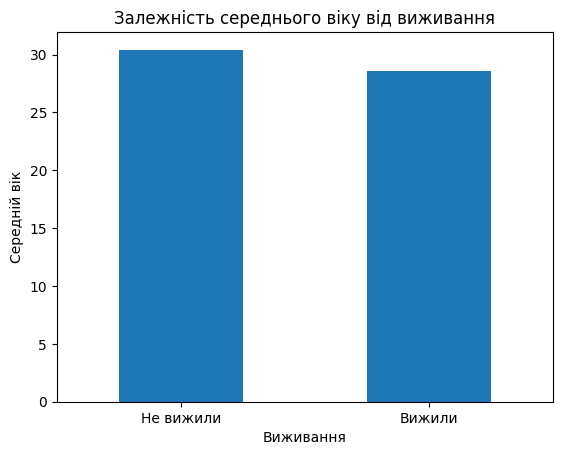

In [27]:
age_survival.plot(kind='bar')
plt.xlabel('Виживання')
plt.ylabel('Середній вік')
plt.title('Залежність середнього віку від виживання')
plt.xticks([0, 1], ['Не вижили', 'Вижили'], rotation=0)
plt.show()